In [27]:
!pip install numpy pandas scipy scikit-learn matplotlib pynput librosa soundfile



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 数据准备说明

这一版支持**任意多个人**的数据，不再写死是2个人。只要把每个人的数据放到
`type_watch_on_laptop/` 下面各自的一个文件夹里就行，**文件夹名就是这个人的标签**
（比如 `Haochen`、`Linwei`、`Qizhe`、`tianrui`），代码会自动扫描这个目录下所有"看起来
像一个人的数据"的子文件夹（判断标准：里面有 `sensor_data/` 这个子文件夹），不需要手动
在代码里列出人名。

目录结构（和手表 App 生成的原始结构一致，`adb pull` 下来直接放进对应人名的文件夹即可）：

```
type_watch_on_laptop/
  Haochen/                   <- 用户1，文件夹名就是标签
    sensor_data/
      1/                      <- 第1次点击"开始"到"结束"之间的一个 session
        Accelerometer_1.csv
        Gyroscope_1.csv
        ...
      2/
        ...
    audio/
      20260722_audio_1.wav    <- 与 sensor_data/1 对应的录音（文件名里的 _1 就是 session id）
      20260722_audio_2.wav
      ...
  Linwei/                     <- 用户2，目录结构完全一样
    sensor_data/
      ...
    audio/
      ...
  Qizhe/                      <- 用户3
    ...
  tianrui/                    <- 用户4
    ...
```

对应的 adb 命令大致是（手表 App 包名是 `com.example.helloworld`，实际以 `AndroidManifest.xml` 为准）：

```
adb pull /sdcard/Android/data/com.example.helloworld/files/sensor_data  type_watch_on_laptop/<人名>/sensor_data
adb pull /sdcard/Android/data/com.example.helloworld/files/audio        type_watch_on_laptop/<人名>/audio
```

同一个人多次收集（多个 session）都可以放在同一个人的文件夹下，代码会自动扫描这个人目录下的
所有 session，不需要手动合并。以后再加第5个人、第6个人，只要在 `type_watch_on_laptop/` 下
新建一个文件夹放数据，不用改任何代码。

> 注意：如果几个人用的是**不同的手表**采集数据，要小心模型学到的可能不是"这个人打字的
> 习惯"，而是"这块手表本身的噪声/灵敏度差异"（即设备指纹而不是人的特征）。理想情况下应该让
> 所有人轮流用同一块手表采集，这样能更好地保证SVM学到的是人的差异。


In [28]:
import os
from collections import Counter
import glob
import numpy as np
import pandas as pd
import scipy.signal
import scipy.io.wavfile
import librosa
import matplotlib.pyplot as plt

# ------------------ 全局参数（按需修改） ------------------

# 存放所有人数据的根目录：下面每个子文件夹代表一个人，文件夹名就是这个人的标签。
DATA_ROOT = r"C:\Users\linwe\Documents\CS Summer Camp\classify\type_watch_on_laptop"


def discover_person_dirs(data_root):
    """
    自动扫描 data_root 下的每个子文件夹，把"里面有 sensor_data/ 子目录"的文件夹当作
    一个人的数据目录，文件夹名就是这个人的标签(比如 Haochen、Linwei、Qizhe、tianrui)。

    这样人数不再写死成固定的两个：以后往 data_root 下面加一个新人的文件夹，
    这里就能自动识别到，不需要改代码。
    """
    person_dirs = {}
    for name in sorted(os.listdir(data_root)):
        full_path = os.path.join(data_root, name)
        if not os.path.isdir(full_path):
            continue  # 跳过普通文件，比如 watch.txt
        if os.path.isdir(os.path.join(full_path, "sensor_data")):
            person_dirs[name] = full_path
    return person_dirs


# 先按真实文件夹名发现每个人的数据目录（内部要用真实路径去读文件）。
real_person_dirs = discover_person_dirs(DATA_ROOT)

# 匿名化：把真实文件夹名（很可能就是同学的真实姓名）换成 "User 1"/"User 2"/... 这样的编号，
# 后面所有的统计结果、图表、分类报告里都只会出现编号，不会出现真实姓名。
# 按真实文件夹名排序后再编号，保证每次运行编号分配都一样（不会因为os.listdir顺序变化而变）。
ANONYMIZED_NAMES = {
    real_name: f"User {i + 1}"
    for i, real_name in enumerate(sorted(real_person_dirs.keys()))
}

# PERSON_DIRS: key 是分类用的标签(匿名化后的 "User N")，value 是这个人的数据文件夹路径。
# 每个文件夹下应该直接包含 sensor_data/ 和 audio/ 两个子文件夹（和手表上的目录结构一致）。
PERSON_DIRS = {ANONYMIZED_NAMES[name]: path for name, path in real_person_dirs.items()}
print(f"发现 {len(PERSON_DIRS)} 个人的数据 (已匿名化): {list(PERSON_DIRS.keys())}")

# 手表播放的扫频信号(chirp)原始音频文件，用来和录音做互相关，找到"整段采集真正开始"的时间点。
# 这就是 senseiworld app 里 res/raw/signal.wav 的源文件，两边必须是同一份文件。
REFERENCE_CHIRP_PATH = (
    r"C:\Users\linwe\Documents\CS Summer Camp\smartwatch-sensor-data-collector-master"
    r"\smartwatch-sensor-data-collector-master\senseiworld\src\main\res\raw\signal.wav"
)

SENSOR_RESAMPLE_HZ = 25          # 把所有传感器统一插值到这个采样率上（原始各传感器采样率不一致）
WINDOW_SEC = 3.0                 # 滑动窗口长度（秒）：每个窗口就是喂给 PCA/SVM 的一条样本
STEP_SEC = 1.0                   # 滑动步长（秒），STEP_SEC < WINDOW_SEC 时相邻窗口会重叠
SENSOR_POINTS_PER_WINDOW = 48    # 每个窗口里，每个传感器通道最终重采样成的固定点数
CHIRP_SKIP_MARGIN_SEC = 0.5      # 跳过开头扫频信号时，额外多跳过的一点余量（秒），避免尾音混进正式数据
AUDIO_SR = 48000                 # 手表录音的采样率，需要和 SensorDataCollector.kt 里的 SAMPLE_RATE 一致
N_MFCC = 13                      # 音频 MFCC 特征阶数


发现 4 个人的数据 (已匿名化): ['User 1', 'User 2', 'User 3', 'User 4']


## 第一步：读取单个 session 的传感器 CSV，并对齐到统一时间轴

手表上不同传感器的采样率完全不一样：加速度计/陀螺仪可能几十Hz一个点，心率/计步器可能几秒才
更新一次，而且不同传感器开始/结束的时间也对不齐。要把它们拼成一个矩阵喂给PCA/SVM，必须先把
每个传感器都**插值到同一个时间网格上**，这样每一行才代表"同一个时刻"的所有传感器读数。


In [29]:
def find_sessions(person_root):
    """
    扫描一个人的数据根目录，找出所有 session。
    一个 session = sensor_data/<id>/ 文件夹 + audio/ 下文件名里带 "_audio_<id>.wav" 的录音文件。
    返回一个列表，每一项是 {"id":..., "sensor_dir":..., "wav_path":...}
    """
    sensor_root = os.path.join(person_root, "sensor_data")
    audio_root = os.path.join(person_root, "audio")

    if not os.path.isdir(sensor_root):
        print(f"[Warning] Sensor directory not found: {sensor_root}")
        return []

    session_ids = sorted(
        int(name) for name in os.listdir(sensor_root)
        if name.isdigit() and os.path.isdir(os.path.join(sensor_root, name))
    )

    sessions = []
    for sid in session_ids:
        sensor_dir = os.path.join(sensor_root, str(sid))
        wav_matches = glob.glob(os.path.join(audio_root, f"*_audio_{sid}.wav"))
        wav_path = wav_matches[0] if wav_matches else None
        if wav_path is None:
            print(f"[Warning] No matching audio file for session {sid}; this session will have no audio features")
        sessions.append({"id": sid, "sensor_dir": sensor_dir, "wav_path": wav_path})
    return sessions


def load_session_sensor_dfs(sensor_dir):
    """
    读取一个 session 文件夹下所有传感器 csv，返回 {传感器名: DataFrame}。
    每个 csv 的列是: timestampMillis, value_0, value_1, ...
    传感器名从文件名里去掉末尾的 "_<sessionid>.csv" 得到，比如 Accelerometer_1.csv -> Accelerometer。
    """
    sensor_dfs = {}
    for csv_path in glob.glob(os.path.join(sensor_dir, "*.csv")):
        filename = os.path.basename(csv_path)
        sensor_name = filename.rsplit("_", 1)[0]  # 去掉末尾的 _<id>.csv
        df = pd.read_csv(csv_path)
        if df.empty or "timestampMillis" not in df.columns:
            continue
        sensor_dfs[sensor_name] = df
    return sensor_dfs


def discover_sensor_schema(all_sensor_dfs_list):
    """
    第一遍扫描：统计所有 session 里出现过的传感器名字，以及每种传感器出现过的最大通道数
    (比如同一种传感器在不同系统版本上返回的数值个数可能不一样，取最大值，不够的用0补齐)。
    这样才能保证所有 session 最终拼出来的特征向量长度和顺序完全一致。
    """
    schema = {}  # 传感器名 -> 最大 value 列数
    for sensor_dfs in all_sensor_dfs_list:
        for name, df in sensor_dfs.items():
            n_values = len([c for c in df.columns if c.startswith("value_")])
            schema[name] = max(schema.get(name, 0), n_values)
    return schema


def build_uniform_sensor_matrix(sensor_dfs, schema, target_hz=SENSOR_RESAMPLE_HZ):
    """
    把一个 session 里所有传感器对齐到同一个统一时间轴(相对session开始的秒数)上。

    做法：
      1. 用这个 session 里所有传感器中最早的时间戳作为 t=0（session 的起点）。
      2. 用最晚的时间戳作为 session 的结束时间。
      3. 按 target_hz 生成一个均匀的时间网格 time_grid。
      4. 对每个传感器的每一列数值，用线性插值(np.interp)映射到这个统一时间网格上；
         网格范围之外的部分用边界值填充（不同传感器开始/结束时间会略有先后）。
      5. 如果这个 session 缺了某个传感器（比如没有气压计），对应的列全部填0，
         这样不同 session 拼出来的矩阵宽度和列的顺序才能保持一致。

    返回: (matrix, channel_names, time_grid)
      matrix: 形状 (n_time_points, n_total_channels)
      channel_names: 长度为 n_total_channels 的列表，例如 ["Accelerometer_0", "Accelerometer_1", ...]
      time_grid: 长度为 n_time_points 的相对时间数组(秒)，time_grid[0] == 0
    """
    if not sensor_dfs:
        return None, None, None

    t0_ms = min(df["timestampMillis"].min() for df in sensor_dfs.values())
    t_end = max(df["timestampMillis"].max() for df in sensor_dfs.values())
    duration_sec = (t_end - t0_ms) / 1000.0
    n_points = max(int(duration_sec * target_hz), 2)
    time_grid = np.linspace(0, duration_sec, n_points)

    channel_names = []
    columns = []
    # 按字母顺序固定传感器遍历顺序，保证每个 session 拼出来的列顺序完全一样
    for sensor_name in sorted(schema.keys()):
        n_values = schema[sensor_name]
        df = sensor_dfs.get(sensor_name)
        for i in range(n_values):
            channel_names.append(f"{sensor_name}_{i}")
            value_col = f"value_{i}"
            if df is not None and value_col in df.columns:
                t_rel = (df["timestampMillis"].to_numpy() - t0_ms) / 1000.0
                values = df[value_col].to_numpy(dtype=float)
                order = np.argsort(t_rel)  # np.interp 要求 t_rel 单调递增
                interp_vals = np.interp(time_grid, t_rel[order], values[order])
            else:
                # 这个 session 没有这个传感器/这一列，用0填充占位
                interp_vals = np.zeros(n_points)
            columns.append(interp_vals)

    matrix = np.stack(columns, axis=1)  # (n_points, n_channels)
    return matrix, channel_names, time_grid


## 第二步：加载录音，并用开头的扫频信号(chirp)做同步

App 在点击"开始"之后，会先播放一段扫频信号（chirp，从低频扫到高频），几乎同时开始录音、
注册传感器监听（见 `SensorCollectionService.startCollecting()`）。这意味着：**扫频信号在录音里
出现的位置，可以近似当作整个采集流程真正开始的时间点**。用互相关(cross-correlation)在录音开头
找到这个位置，就能把音频的时间轴和传感器的时间轴对齐到同一个"相对session开始的秒数"上
（两者之间可能还有零点几秒的误差，但相对我们几秒钟长度的窗口可以忽略）。

另外，扫频信号本身对区分"是谁在打字"没有意义——两个人的这段声音理论上是一样的，如果不跳过，
模型反而可能把"是否包含扫频信号残留"当成捷径特征，所以正式切窗口时会跳过这一段。


In [30]:
def load_wav_mono(path):
    """用 scipy 读取 wav 文件，返回 (采样率, 单声道 float32 信号, 已归一化到约[-1, 1])。"""
    sr, data = scipy.io.wavfile.read(path)
    if data.ndim > 1:
        data = data.mean(axis=1)
    data = data.astype(np.float32)
    if np.issubdtype(np.dtype(np.int16), np.integer) and (data.max() > 1.0 or data.min() < -1.0):
        data = data / 32768.0  # 16-bit PCM -> [-1, 1]
    return sr, data


def load_reference_chirp(path, target_sr):
    """加载参考扫频信号，如果采样率和录音不一致就重采样到一致，方便后面做互相关。"""
    ref_sr, ref = load_wav_mono(path)
    if ref_sr != target_sr:
        ref = scipy.signal.resample(ref, int(len(ref) * target_sr / ref_sr))
    return ref


def find_chirp_offset(recording, sr, reference, search_sec=8.0):
    """
    在录音开头 search_sec 秒内，用互相关找参考扫频信号(chirp)的起始位置。
    返回 chirp_start_sample：扫频信号在录音里开始的采样点下标。
    """
    search_len = min(len(recording), int(search_sec * sr))
    search_region = recording[:search_len]
    correlation = scipy.signal.correlate(search_region, reference, mode="valid")
    chirp_start_sample = int(np.argmax(np.abs(correlation)))
    return chirp_start_sample


## 第三步：滑动窗口切分 + 特征提取

把每个 session 按 `WINDOW_SEC` 秒长、`STEP_SEC` 秒步长切成若干个有重叠的窗口，每个窗口就是
最终喂给 PCA/SVM 的一条样本，包含两部分特征：

- **传感器特征**：把窗口内的传感器矩阵重采样成固定的 `SENSOR_POINTS_PER_WINDOW` 个点后展平，
  和 notebook 里原来 PCA 部分预期的 `resampled_segments` 是同一种东西。
- **音频特征**：不直接用原始48kHz波形（维度太高，且大部分内容和"谁在打字"无关），而是提取一组
  能描述敲击声音色和响度的统计特征（MFCC、能量、过零率、频谱形状等）。


In [31]:
def slice_and_resample_sensor(matrix, time_grid, start_t, end_t, target_len=SENSOR_POINTS_PER_WINDOW):
    """
    从整段 session 的传感器矩阵里截取 [start_t, end_t) 这一段窗口，再强制重采样成固定的
    target_len 个点（不管原始这段时间里实际采到了多少个点），保证每个窗口最终维度一致，
    才能塞进同一个特征矩阵。
    """
    mask = (time_grid >= start_t) & (time_grid < end_t)
    segment = matrix[mask]
    if segment.shape[0] < 2:
        return None
    return scipy.signal.resample(segment, target_len, axis=0)


def extract_audio_features(audio_segment, sr, n_mfcc=N_MFCC):
    """
    从一段音频窗口里提取一组统计特征：
      - MFCC(梅尔倒谱系数)的均值和标准差：描述声音的"音色"，对键盘敲击声比较敏感
      - RMS能量：声音响度
      - 过零率(zero crossing rate)：敲击类的瞬态声音过零率通常偏高
      - 频谱质心 / 频谱带宽 / 频谱滚降：描述能量在频率上的分布形状
    """
    min_len = int(sr * 0.05)
    if audio_segment.size < min_len:
        return None

    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    rms = librosa.feature.rms(y=audio_segment).mean()
    zcr = librosa.feature.zero_crossing_rate(audio_segment).mean()
    centroid = librosa.feature.spectral_centroid(y=audio_segment, sr=sr).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_segment, sr=sr).mean()
    rolloff = librosa.feature.spectral_rolloff(y=audio_segment, sr=sr).mean()

    return np.concatenate([
        mfcc_mean, mfcc_std,
        [rms, zcr, centroid, bandwidth, rolloff],
    ])


AUDIO_FEATURE_DIM = N_MFCC * 2 + 5  # 与 extract_audio_features 返回的维度保持一致


## 第四步：遍历两个人的所有 session，生成训练样本

这里额外记录了 `groups`（每条样本来自哪个 session），是为了后面训练/测试集划分时按
session整体划分——同一个session里相邻窗口高度重叠、高度相关，如果随机打乱后按窗口划分，
很容易让同一个session的窗口同时出现在训练集和测试集里，模型"背下"了这个session，
导致测试准确率虚高但并不代表真的能区分出两个人。


In [32]:
# ---------- 第一遍扫描：收集所有 session 的传感器数据，确定统一的传感器 schema ----------
all_sessions = []  # 每一项: {"label":..., "id":..., "sensor_dfs":..., "wav_path":...}
for label, person_root in PERSON_DIRS.items():
    for sess in find_sessions(person_root):
        sensor_dfs = load_session_sensor_dfs(sess["sensor_dir"])
        if not sensor_dfs:
            print(f"[Warning] label={label} session={sess['id']} has no sensor data, skipping")
            continue
        all_sessions.append({
            "label": label,
            "id": sess["id"],
            "sensor_dfs": sensor_dfs,
            "wav_path": sess["wav_path"],
        })

print(f"Found {len(all_sessions)} valid sessions")

SENSOR_SCHEMA = discover_sensor_schema([s["sensor_dfs"] for s in all_sessions])
print("Unified sensor schema (sensor name: channel count):")
for name, n in sorted(SENSOR_SCHEMA.items()):
    print(f"  {name}: {n}")

reference_chirp = load_reference_chirp(REFERENCE_CHIRP_PATH, AUDIO_SR)
chirp_skip_sec = len(reference_chirp) / AUDIO_SR + CHIRP_SKIP_MARGIN_SEC

# ---------- 第二遍：逐个 session 切滑窗，生成训练样本 ----------
resampled_segments = []   # 每个窗口的传感器数据，shape=(SENSOR_POINTS_PER_WINDOW, n_channels)
audio_feature_list = []   # 每个窗口的音频特征向量
labels = []                # 每个窗口对应的标签(人名字符串，比如 "Haochen")
groups = []                # 每个窗口来自哪个session，格式 "label_sessionid"，划分train/test时要用

for sess in all_sessions:
    matrix, channel_names, time_grid = build_uniform_sensor_matrix(sess["sensor_dfs"], SENSOR_SCHEMA)
    if matrix is None:
        continue
    session_duration = time_grid[-1]

    # ---- 处理音频：加载 + 用扫频信号找同步起点 ----
    audio = None
    audio_t0_sec = 0.0
    if sess["wav_path"] is not None:
        sr, audio = load_wav_mono(sess["wav_path"])
        chirp_start_sample = find_chirp_offset(audio, sr, reference_chirp)
        audio_t0_sec = chirp_start_sample / sr  # 音频里"采集真正开始"对应的时间点

    # ---- 滑动窗口：从跳过开头扫频信号之后开始，直到session结束 ----
    window_start = 0  #先不跳过扫频信号 chirp_skip_sec
    while window_start + WINDOW_SEC <= session_duration:
        window_end = window_start + WINDOW_SEC

        sensor_seg = slice_and_resample_sensor(matrix, time_grid, window_start, window_end)
        if sensor_seg is None:
            window_start += STEP_SEC
            continue

        audio_feat = None
        if audio is not None:
            a_start = max(int((audio_t0_sec + window_start) * AUDIO_SR), 0)
            a_end = min(int((audio_t0_sec + window_end) * AUDIO_SR), len(audio))
            audio_feat = extract_audio_features(audio[a_start:a_end], AUDIO_SR)

        if audio_feat is None:
            # 没有音频/音频特征提取失败时用0向量占位，保证特征矩阵维度一致
            audio_feat = np.zeros(AUDIO_FEATURE_DIM)

        resampled_segments.append(sensor_seg)
        audio_feature_list.append(audio_feat)
        labels.append(sess["label"])
        groups.append(f"{sess['label']}_{sess['id']}")

        window_start += STEP_SEC

print(f"Generated {len(labels)} window samples")
label_counts = Counter(labels)
for name in sorted(label_counts):
    print(f"  {name}: {label_counts[name]} windows")


Found 80 valid sessions
Unified sensor schema (sensor name: channel count):
  Accelerometer: 3
  Game_Rotation_Vector: 4
  Gravity_Sensor: 3
  Gyroscope: 3
  Gyroscope_Uncalibrated: 6
  Heart_Rate: 1
  Light_Sensor: 1
  Linear_Acceleration: 3
  Magnetic_Field: 3
  Magnetic_Field_Uncalibrated: 6
  Off_Body_Detect: 1
  Pressure: 1
  Rotation_Vector: 5
  Step_Counter: 1


C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 161196 bytes, expected 351404 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 67592 bytes, expected 389804 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 69844 bytes, expected 364844 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 67592 bytes, expected 353324 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 83704 bytes, expected 395564 bytes from hea

Generated 156 window samples
  User 1: 28 windows
  User 2: 23 windows
  User 3: 58 windows
  User 4: 47 windows


C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 49054 bytes, expected 435884 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 48510 bytes, expected 410924 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 49500 bytes, expected 460844 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 48510 bytes, expected 403244 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 48782 bytes, expected 432044 bytes from head

In [33]:
# 展示sensor_dfs里的数据
for label, df in sensor_dfs.items():
    print(f" {label}, shape: {df.shape}")
    display(df.head())

 Accelerometer, shape: (106, 4)


,timestampMillis,value_0,value_1,value_2
0,1784747978412,-0.098162,-1.314417,9.761160
1,1784747978412,-0.174777,-1.156399,9.749189
2,1784747978412,-0.193930,-1.288081,9.765948
3,1784747978426,-0.124498,-1.233014,9.742006
4,1784747978477,-0.172383,-1.132457,9.701305


 Game_Rotation_Vector, shape: (26, 5)


,timestampMillis,value_0,value_1,value_2,value_3
0,1784747978538,-0.061447,0.001307,0.094865,0.993591
1,1784747978740,-0.061674,0.001085,0.094699,0.993593
2,1784747978943,-0.061784,0.000574,0.094564,0.993599
3,1784747979145,-0.061396,0.001121,0.094329,0.993645
4,1784747979343,-0.061405,0.001689,0.093771,0.993696


 Gyroscope, shape: (33, 4)


...

,timestampMillis,value_0
0,1784747978537,989.14990
1,1784747978740,989.14746
2,1784747978943,989.14500
3,1784747979145,989.14136
4,1784747979343,989.13620


 Rotation_Vector, shape: (26, 6)


,timestampMillis,value_0,value_1,value_2,value_3,value_4
0,1784747978538,-0.062452,0.000323,0.095292,0.993488,246.0
1,1784747978740,-0.062209,0.000533,0.095156,0.993516,246.0
2,1784747978943,-0.062039,0.000225,0.095036,0.993538,246.0
3,1784747979145,-0.061492,0.000972,0.094814,0.993593,246.0
4,1784747979343,-0.061446,0.001599,0.094263,0.993647,246.0


 Step_Counter, shape: (1, 2)


,timestampMillis,value_0
0,1784747978412,6681.0


# PCA

In [34]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# X_sensor: 把每个窗口的传感器矩阵展平成一维向量 (SENSOR_POINTS_PER_WINDOW * n_channels,)
X_sensor = np.array([seg.flatten() for seg in resampled_segments])
# X_audio: 每个窗口的音频统计特征
X_audio = np.array(audio_feature_list)

# 拼接传感器特征和音频特征，作为最终喂给 PCA/SVM 的特征向量
X = np.hstack([X_sensor, X_audio])
y = np.array(labels)
groups = np.array(groups)  # 记录每条样本来自哪个session，供后面分组切分train/test使用

print("Sensor feature dim:", X_sensor.shape, " Audio feature dim:", X_audio.shape, " Combined:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)  # 保留95%方差，也可以先试固定成分数比如20
X_pca = pca.fit_transform(X_scaled)
print("Reduced dim:", X_pca.shape, "Number of components used:", pca.n_components_)


Sensor feature dim: (156, 1968)  Audio feature dim: (156, 31)  Combined: (156, 1999)
Reduced dim: (156, 48) Number of components used: 48


# SVM

In [35]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 注意：这里不能像普通数据那样随机划分 train/test！
# 同一个 session 内部相邻的滑动窗口有大量重叠、高度相关(比如同一段打字过程的连续片段)，
# 如果随机划分，很可能同一个 session 的窗口一部分进 train 一部分进 test，模型学到的其实是
# "记住了这个session"而不是"区分两个人"，导致准确率虚高。所以要按 session (即 groups)
# 整体划分，保证同一个 session 只会出现在 train 或 test 的一边。

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X_pca, y, groups=groups))

X_train, X_test = X_pca[train_idx], X_pca[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
class_names = sorted(set(y))  # 固定类别顺序，方便和下面的混淆矩阵对应
print(classification_report(y_test, y_pred, labels=class_names))

# 用带行列标签的表格展示混淆矩阵，人数一多，光看数字矩阵很容易数错行列对应谁
cm = confusion_matrix(y_test, y_pred, labels=class_names)
cm_df = pd.DataFrame(cm, index=[f"true_{n}" for n in class_names],
                      columns=[f"pred_{n}" for n in class_names])
print(cm_df)

# 数据量小的话，建议用分组交叉验证代替单次划分，结果更可靠。
# GroupKFold 保证同一个session不会同时出现在某一折的 train 和 test 里。
n_groups = len(set(groups))
cv = GroupKFold(n_splits=min(5, n_groups))
scores = cross_val_score(clf, X_pca, y, groups=groups, cv=cv)
print("Group cross-validation accuracy:", scores.mean(), "+/-", scores.std())


              precision    recall  f1-score   support

      User 1       1.00      0.90      0.95        10
      User 2       1.00      1.00      1.00         8
      User 3       1.00      1.00      1.00        13
      User 4       0.93      1.00      0.97        14

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45

             pred_User 1  pred_User 2  pred_User 3  pred_User 4
true_User 1            9            0            0            1
true_User 2            0            8            0            0
true_User 3            0            0           13            0
true_User 4            0            0            0           14
Group cross-validation accuracy: 0.9679435483870968 +/- 0.035339239700976605


## (可选) 结果可视化：PCA 前两个主成分散点图

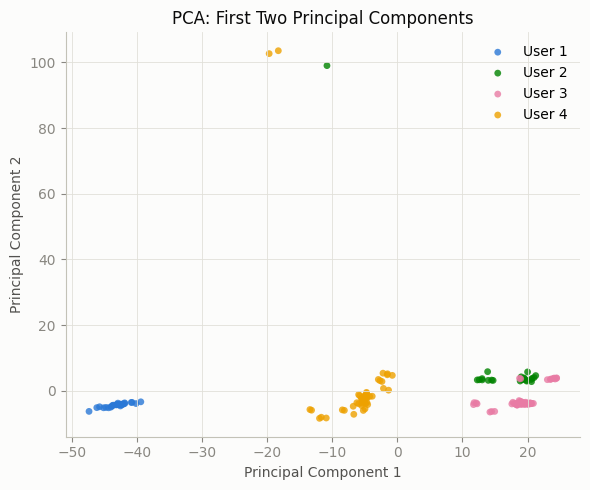

In [36]:
# 用前两个主成分画散点图，直观看看不同人的数据是否能分开。
# 注意这只是辅助诊断用的图，不是最终判断依据——PCA前两维不一定包含最有区分度的信息，
# 真正的分类效果要看上面 SVM 的分类报告和交叉验证准确率。

fig, ax = plt.subplots(figsize=(6, 5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# 分类色板：固定顺序的8个区分度高的颜色，人数在8个以内都不会撞色；
# 超过8个人会循环复用颜色（这种情况下建议改用小多图而不是硬塞进一张散点图里）
CATEGORY_PALETTE = [
    "#2a78d6", "#008300", "#e87ba4", "#eda100",
    "#1baf7a", "#eb6834", "#4a3aa7", "#e34948",
]
person_names = sorted(set(y))
colors = {name: CATEGORY_PALETTE[i % len(CATEGORY_PALETTE)] for i, name in enumerate(person_names)}

for name in person_names:
    mask = y == name
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=24, alpha=0.8, color=colors[name], label=name,
        edgecolors="none",
    )

ax.set_xlabel("Principal Component 1", color="#52514e")
ax.set_ylabel("Principal Component 2", color="#52514e")
ax.set_title("PCA: First Two Principal Components", color="#0b0b0b")
ax.tick_params(colors="#898781")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.grid(True, color="#e1e0d9", linewidth=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## (可选) 探索性分析：扫频信号经过手腕之后，会不会带有因人而异的特征

之前提到的论文《You Define Your Biometrics》的核心思路是：主动播放一个探测信号，让它经过
人的手/身体之后被吸收、反射、折射，不同人的手因为大小、骨骼、含水量等不同，最终被麦克风收到的
信号也会有细微差异——这可以作为一种"生物特征"。

我们的扫频信号本来只是用来做音频/传感器时间同步的，但既然设备在开始收集数据时都会播放它，
不妨顺便看看：**同一块手表播放的同一段扫频信号，经过不同人的手腕之后，录到的声音在各个频率上的
响应强弱，是不是因人而异**。

做法：把每个 session 里实际录到的那一段 chirp，和"标准答案"(`REFERENCE_CHIRP_PATH` 原始文件)
做对比，算出每个频率上"录到的能量 / 原始播放的能量"的比值（约等于"整个系统在这个频率上的响应
增益"），按用户分组画出来看看两条曲线是否有系统性差异。

> 注意：手表的喇叭和麦克风离得很近，录到的响应主要还是"喇叭→空气→麦克风"这条最短路径的设备
> 本身特性，如果几个人用的是**同一块手表**，这部分是完全一样的；只有声音经过手腕/皮肤传导、或者
> 手表贴合手腕的松紧程度改变了共振腔体这部分，才可能因人而异。所以这里更多是探索性质——如果几条
> 曲线几乎完全重合，说明这个信号本身可能不太能区分人（至少对手表这种佩戴方式来说，不像论文里手柄
> 握在手心那么明显），这也是一个有价值的（阴性）结论，可以据此决定要不要把这部分特征加进正式的
> 分类流程。


In [37]:
def extract_chirp_response(audio, sr, chirp_start_sample, reference_chirp, n_bands=32, f_min=100.0):
    """
    比较"实际录到的chirp"和"原始播放的chirp"，估计整个系统在各个频段上的响应增益(dB)。

    做法：
      1. 从录音里截出和参考chirp等长的一段（从 chirp_start_sample 开始）。
      2. 分别对录到的片段和参考片段做加窗(Hanning)后的FFT，得到频谱。
      3. 对每个频率点算功率比 |录音|^2 / |参考|^2，再按对数频率分成 n_bands 个频段取平均，
         转成dB，得到一条"频率响应曲线"（长度固定为 n_bands，跟原始chirp的采样点数无关，
         方便不同session之间直接比较/画在同一张图上）。

    返回: (response_db, band_centers)
      response_db: 长度 n_bands 的响应曲线(dB)
      band_centers: 每个频段的中心频率(Hz)，画图时当x轴用
    """
    n = len(reference_chirp)
    recorded = np.asarray(audio[chirp_start_sample: chirp_start_sample + n], dtype=np.float64)
    if len(recorded) < n:
        recorded = np.pad(recorded, (0, n - len(recorded)))

    window = np.hanning(n)
    rec_spec = np.fft.rfft(recorded * window)
    ref_spec = np.fft.rfft(reference_chirp * window)
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)

    eps = 1e-10
    power_ratio = (np.abs(rec_spec) ** 2) / (np.abs(ref_spec) ** 2 + eps)

    f_max = sr / 2
    band_edges = np.logspace(np.log10(f_min), np.log10(f_max), n_bands + 1)
    response_db = np.full(n_bands, np.nan)
    band_centers = np.sqrt(band_edges[:-1] * band_edges[1:])

    for i in range(n_bands):
        mask = (freqs >= band_edges[i]) & (freqs < band_edges[i + 1])
        if mask.any():
            response_db[i] = 10 * np.log10(power_ratio[mask].mean() + eps)

    return response_db, band_centers


In [38]:
CHIRP_RESPONSE_BANDS = 32     # 频率响应曲线分成多少段
CHIRP_RESPONSE_FMIN = 100.0   # 分析的最低频率(Hz)；chirp在太低频的能量本来就很弱，参考意义不大

# 这里重新逐个session加载音频、找chirp位置，而不是复用第四步主循环里的结果——
# 是为了避免把所有session的完整录音都同时留在内存里，用多一点计算时间换取内存占用更低。
chirp_response_list = []
chirp_response_labels = []
chirp_response_session_ids = []
band_centers = None

for sess in all_sessions:
    if sess["wav_path"] is None:
        continue
    sr, audio = load_wav_mono(sess["wav_path"])
    chirp_start_sample = find_chirp_offset(audio, sr, reference_chirp)
    response_db, band_centers = extract_chirp_response(
        audio, sr, chirp_start_sample, reference_chirp,
        n_bands=CHIRP_RESPONSE_BANDS, f_min=CHIRP_RESPONSE_FMIN,
    )
    chirp_response_list.append(response_db)
    chirp_response_labels.append(sess["label"])
    chirp_response_session_ids.append(f"{sess['label']}_{sess['id']}")

chirp_response_matrix = np.array(chirp_response_list)   # (n_sessions, CHIRP_RESPONSE_BANDS)
chirp_response_labels = np.array(chirp_response_labels)

print(f"Collected chirp response for {len(chirp_response_labels)} sessions")
print(f"Response matrix shape: {chirp_response_matrix.shape}")


C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 161196 bytes, expected 351404 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 67592 bytes, expected 389804 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 69844 bytes, expected 364844 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 67592 bytes, expected 353324 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 83704 bytes, expected 395564 bytes from hea

Collected chirp response for 80 sessions
Response matrix shape: (80, 32)


C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 49500 bytes, expected 453164 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 48782 bytes, expected 474284 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 50490 bytes, expected 553004 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 44822 bytes, expected 439724 bytes from header.
  sr, data = scipy.io.wavfile.read(path)
C:\Users\linwe\AppData\Local\Temp\ipykernel_25760\4226280221.py:3: WavFileWarning: Reached EOF prematurely; finished at 50490 bytes, expected 458924 bytes from head

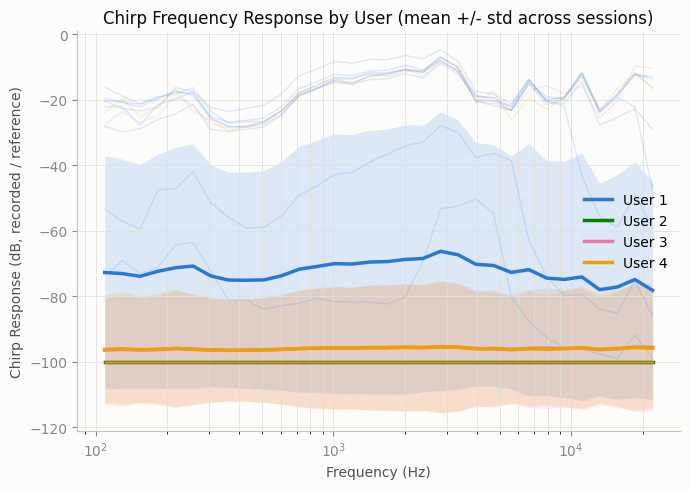

In [39]:
# 按用户画出频率响应曲线的均值+标准差范围，直观看两个人是否有系统性差异。
# 细浅线是每个session各自的曲线(展示同一个人内部的波动范围)，粗线是这个人的平均曲线。

fig, ax = plt.subplots(figsize=(7, 5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

CATEGORY_PALETTE = [
    "#2a78d6", "#008300", "#e87ba4", "#eda100",
    "#1baf7a", "#eb6834", "#4a3aa7", "#e34948",
]
chirp_person_names = sorted(set(chirp_response_labels))
colors = {name: CATEGORY_PALETTE[i % len(CATEGORY_PALETTE)] for i, name in enumerate(chirp_person_names)}

for name in chirp_person_names:
    mask = chirp_response_labels == name
    if not mask.any():
        continue
    curves = chirp_response_matrix[mask]
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)

    for curve in curves:
        ax.plot(band_centers, curve, color=colors[name], alpha=0.15, linewidth=1)

    ax.plot(band_centers, mean_curve, color=colors[name], linewidth=2.5, label=name)
    ax.fill_between(
        band_centers, mean_curve - std_curve, mean_curve + std_curve,
        color=colors[name], alpha=0.15, linewidth=0,
    )

ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)", color="#52514e")
ax.set_ylabel("Chirp Response (dB, recorded / reference)", color="#52514e")
ax.set_title("Chirp Frequency Response by User (mean +/- std across sessions)", color="#0b0b0b")
ax.tick_params(colors="#898781")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.grid(True, which="both", color="#e1e0d9", linewidth=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


如果蓝色（用户A）和橙色（用户B）两条均值曲线在某些频段明显分开、阴影带不怎么重叠，说明这个探测信号确实带有因人而异的信息，可以考虑把这32维响应曲线也作为特征加进正式的PCA/SVM流程（拼到现有的传感器+音频特征后面）；如果两条曲线几乎完全贴在一起，说明至少对手表这种佩戴方式，这个效应弱到可以忽略，那就没必要往正式流程里加了。

# 深度学习 (CNN)：和 SVM 做对比

前面PCA+SVM的做法是：人工设计特征(重采样传感器窗口 + MFCC等音频统计量) -> PCA降维 -> SVM分类。
这里换一种思路：**不做PCA降维，直接把传感器窗口的原始时间序列喂给一个1D卷积神经网络(CNN)**，
让网络自己学怎么从波形里提取有区分度的特征；音频部分还是用已经提取好的统计特征，走一个全连接分支，
最后两个分支拼在一起做分类。这样可以直接对比"人工特征+经典机器学习"和"端到端深度学习"在这份数据上
谁的效果更好。

> **提醒**：深度学习通常需要大量数据才能发挥优势。我们现在总共只有156个窗口样本、80个session、
> 4个类别——这个数据量对CNN来说非常小，很容易过拟合。这里会尽量用小模型、Dropout、
> 提前停止(early stopping)、以及和SVM完全一样的按session分组的数据切分方式来公平对比，
> 但**如果CNN的结果不如SVM，并不代表CNN这个方法本身不好，很可能只是数据量不够喂饱一个神经网络**——
> 这本身也是一个值得记录的、有意义的对比结论。


In [40]:
!pip install tensorflow



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 第一步：准备CNN需要的输入格式

- **传感器分支**：直接用 `resampled_segments`（前面已经切好、重采样成固定长度的窗口），
  形状是 `(样本数, SENSOR_POINTS_PER_WINDOW, 传感器通道数)`，正好是1D CNN期待的
  "(时间步, 通道)"格式，不需要像PCA那样先展平成一维向量。
- **音频分支**：还是用已经提取好的 `audio_feature_list`（MFCC均值/方差、能量、过零率等统计量），
  走一个全连接(Dense)分支，不需要卷积。
- **标准化**：分别对传感器和音频两部分做标准化，**只用训练集的统计量去fit**，避免测试集的信息
  提前泄漏到标准化步骤里。
- **切分方式**：直接复用前面SVM那一步已经算好的 `train_idx` / `test_idx`（同样是按session
  分组切分的），这样CNN和SVM是在完全相同的训练集/测试集上比较，结果才有可比性。


In [41]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

# 传感器输入：直接用滑窗后的原始时间序列，不经过PCA。形状 (样本数, 时间步, 通道数)
X_sensor_cnn = np.array(resampled_segments)
n_samples, n_timesteps, n_channels = X_sensor_cnn.shape

# 音频输入：还是用之前提取好的统计特征
X_audio_cnn = np.array(audio_feature_list)
n_audio_features = X_audio_cnn.shape[1]

# 标签：CNN需要整数/one-hot形式，而不是SVM那种直接用字符串
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y)  # y 是前面PCA那一步算好的 np.array(labels)，内容是 "User 1".."User 4"
num_classes = len(label_encoder.classes_)
print("类别:", list(label_encoder.classes_))
print(f"传感器输入形状: {X_sensor_cnn.shape}, 音频输入维度: {n_audio_features}, 类别数: {num_classes}")


def make_scalers(train_idx):
    """只用给定的train_idx拟合传感器和音频两个StandardScaler，避免测试集信息泄漏到标准化里。"""
    s_scaler = StandardScaler()
    s_scaler.fit(X_sensor_cnn[train_idx].reshape(-1, n_channels))
    a_scaler = StandardScaler()
    a_scaler.fit(X_audio_cnn[train_idx])
    return s_scaler, a_scaler


def apply_scalers(idx, s_scaler, a_scaler):
    """把拟合好的scaler应用到任意一组样本(索引idx)上，返回CNN需要的(传感器, 音频)两个输入。"""
    sensor_scaled = s_scaler.transform(
        X_sensor_cnn[idx].reshape(-1, n_channels)
    ).reshape(len(idx), n_timesteps, n_channels)
    audio_scaled = a_scaler.transform(X_audio_cnn[idx])
    return sensor_scaled, audio_scaled


# 复用SVM那一步已经切好的 train_idx / test_idx (同一份按session分组的切分)，保证公平对比
print(f"训练集: {len(train_idx)} 个窗口, 测试集: {len(test_idx)} 个窗口 (和SVM那步完全一致)")


类别: [np.str_('User 1'), np.str_('User 2'), np.str_('User 3'), np.str_('User 4')]
传感器输入形状: (156, 48, 41), 音频输入维度: 31, 类别数: 4
训练集: 111 个窗口, 测试集: 45 个窗口 (和SVM那步完全一致)


## 第二步：搭建模型

- **传感器分支**：两层 `Conv1D`（在时间轴上滑动，找局部的敲击/振动模式）+ `BatchNormalization`
  + `MaxPooling1D`，最后用 `GlobalAveragePooling1D` 把每个通道压成一个数（比直接`Flatten`参数少
  很多，样本这么少的情况下更不容易过拟合）。
- **音频分支**：已经是统计特征了，一层 `Dense` 就够。
- 两个分支的输出拼接(`concatenate`)起来，再过一层 `Dense`，最后 `softmax` 输出4个类别的概率。
- `Dropout` 用来缓解过拟合——毕竟我们数据量真的很小。


In [42]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

tf.random.set_seed(42)


def build_cnn_model(n_timesteps, n_channels, n_audio_features, num_classes):
    # 传感器分支：1D卷积，在时间轴上找局部的敲击/振动模式
    sensor_input = layers.Input(shape=(n_timesteps, n_channels), name="sensor_input")
    x = layers.Conv1D(32, kernel_size=3, activation="relu", padding="same")(sensor_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)  # 比Flatten参数更少，没那么容易过拟合
    x = layers.Dropout(0.3)(x)

    # 音频分支：已经是统计特征了，用全连接层处理
    audio_input = layers.Input(shape=(n_audio_features,), name="audio_input")
    a = layers.Dense(32, activation="relu")(audio_input)
    a = layers.Dropout(0.3)(a)

    # 两个分支拼接后再过几层全连接，输出分类结果
    merged = layers.concatenate([x, a])
    merged = layers.Dense(32, activation="relu")(merged)
    merged = layers.Dropout(0.3)(merged)
    output = layers.Dense(num_classes, activation="softmax")(merged)

    model = Model(inputs=[sensor_input, audio_input], outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


build_cnn_model(n_timesteps, n_channels, n_audio_features, num_classes).summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 48, 41)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 48, 32)    │      3,968 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 24, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_input         │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,024 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      3,104 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │        132 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,820 (57.89 KB)

 Trainable params: 14,628 (57.14 KB)

 Non-trainable params: 192 (768.00 B)

## 第三步：训练一次，和SVM的单次划分结果对比

从训练集里再单独切一部分出来当验证集(同样按session分组切，不能随机切窗口)，用来做提前停止；
测试集(`test_idx`)全程不参与训练和调参，只在最后评估一次——和前面SVM那一步的评估方式对齐。


In [43]:
from tensorflow.keras.utils import to_categorical

y_onehot = to_categorical(y_int, num_classes=num_classes)

# 从训练集里再切一部分当验证集，同样按session分组，避免同一个session的窗口既在训练又在验证里
train_groups = groups[train_idx]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
sub_train_pos, sub_val_pos = next(gss_val.split(train_idx, groups=train_groups))
inner_train_idx = train_idx[sub_train_pos]
inner_val_idx = train_idx[sub_val_pos]

print(f"内部训练集: {len(inner_train_idx)}, 验证集: {len(inner_val_idx)}, "
      f"测试集(最终评估用，训练过程中不会看到): {len(test_idx)}")

s_scaler, a_scaler = make_scalers(inner_train_idx)
sensor_train, audio_train = apply_scalers(inner_train_idx, s_scaler, a_scaler)
sensor_val, audio_val = apply_scalers(inner_val_idx, s_scaler, a_scaler)
sensor_test, audio_test = apply_scalers(test_idx, s_scaler, a_scaler)

cnn_model = build_cnn_model(n_timesteps, n_channels, n_audio_features, num_classes)

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history = cnn_model.fit(
    {"sensor_input": sensor_train, "audio_input": audio_train},
    y_onehot[inner_train_idx],
    validation_data=(
        {"sensor_input": sensor_val, "audio_input": audio_val},
        y_onehot[inner_val_idx],
    ),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)


内部训练集: 88, 验证集: 23, 测试集(最终评估用，训练过程中不会看到): 45
Epoch 1/100
6/6 - 1s - 185ms/step - accuracy: 0.2500 - loss: 1.6977 - val_accuracy: 0.1304 - val_loss: 10.6392
Epoch 2/100
6/6 - 0s - 11ms/step - accuracy: 0.4773 - loss: 1.0956 - val_accuracy: 0.3043 - val_loss: 10.2809
Epoch 3/100
6/6 - 0s - 11ms/step - accuracy: 0.7955 - loss: 0.6530 - val_accuracy: 0.3478 - val_loss: 9.9087
Epoch 4/100
6/6 - 0s - 11ms/step - accuracy: 0.8409 - loss: 0.4923 - val_accuracy: 0.4783 - val_loss: 9.3730
Epoch 5/100
6/6 - 0s - 12ms/step - accuracy: 0.9432 - loss: 0.3875 - val_accuracy: 0.4783 - val_loss: 9.0913
Epoch 6/100
6/6 - 0s - 11ms/step - accuracy: 0.9659 - loss: 0.2552 - val_accuracy: 0.4783 - val_loss: 9.0111
Epoch 7/100
6/6 - 0s - 10ms/step - accuracy: 0.9432 - loss: 0.2309 - val_accuracy: 0.4783 - val_loss: 9.1585
Epoch 8/100
6/6 - 0s - 11ms/step - accuracy: 1.0000 - loss: 0.1460 - val_accuracy: 0.4783 - val_loss: 9.4373
Epoch 9/100
6/6 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.1362 - val_accurac

## 训练曲线

看训练集和验证集的loss/accuracy曲线走势：如果训练集准确率一路涨、验证集不涨甚至下降，
就是过拟合的典型信号(数据量太小很容易出现这种情况)；两条线一起涨、差距不大，说明模型学到的
东西还比较靠谱。


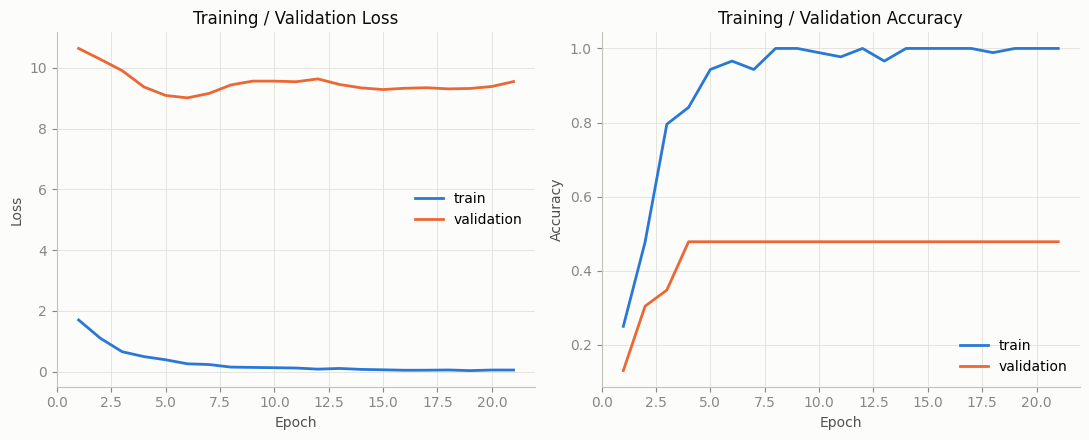

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#fcfcfb")

for ax in axes:
    ax.set_facecolor("#fcfcfb")
    ax.tick_params(colors="#898781")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#c3c2b7")
    ax.grid(True, color="#e1e0d9", linewidth=0.6)

epochs_range = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_range, history.history["loss"], color="#2a78d6", linewidth=2, label="train")
axes[0].plot(epochs_range, history.history["val_loss"], color="#eb6834", linewidth=2, label="validation")
axes[0].set_xlabel("Epoch", color="#52514e")
axes[0].set_ylabel("Loss", color="#52514e")
axes[0].set_title("Training / Validation Loss", color="#0b0b0b")
axes[0].legend(frameon=False)

axes[1].plot(epochs_range, history.history["accuracy"], color="#2a78d6", linewidth=2, label="train")
axes[1].plot(epochs_range, history.history["val_accuracy"], color="#eb6834", linewidth=2, label="validation")
axes[1].set_xlabel("Epoch", color="#52514e")
axes[1].set_ylabel("Accuracy", color="#52514e")
axes[1].set_title("Training / Validation Accuracy", color="#0b0b0b")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 测试集上的最终结果

用完全没参与训练/调参的测试集(`test_idx`)评估一次，格式和前面SVM那一步的
`classification_report` / 混淆矩阵完全对齐，方便直接比较数字。


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred_probs = cnn_model.predict({"sensor_input": sensor_test, "audio_input": audio_test}, verbose=0)
y_test_pred_int = np.argmax(y_test_pred_probs, axis=1)
y_test_true_int = np.argmax(y_onehot[test_idx], axis=1)

y_test_pred_names = label_encoder.inverse_transform(y_test_pred_int)
y_test_true_names = label_encoder.inverse_transform(y_test_true_int)

class_names_cnn = sorted(set(y))
print("CNN 测试集分类报告:")
print(classification_report(y_test_true_names, y_test_pred_names, labels=class_names_cnn))

cm_cnn = confusion_matrix(y_test_true_names, y_test_pred_names, labels=class_names_cnn)
cm_cnn_df = pd.DataFrame(
    cm_cnn,
    index=[f"true_{n}" for n in class_names_cnn],
    columns=[f"pred_{n}" for n in class_names_cnn],
)
print(cm_cnn_df)


CNN 测试集分类报告:
              precision    recall  f1-score   support

      User 1       0.83      1.00      0.91        10
      User 2       1.00      1.00      1.00         8
      User 3       1.00      1.00      1.00        13
      User 4       1.00      0.86      0.92        14

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

             pred_User 1  pred_User 2  pred_User 3  pred_User 4
true_User 1           10            0            0            0
true_User 2            0            8            0            0
true_User 3            0            0           13            0
true_User 4            2            0            0           12


## 分组交叉验证：更可靠的整体准确率对比

单次划分的结果运气成分比较大(数据量小的时候尤其明显)，这里用和SVM那一步同样的
`GroupKFold` 分组交叉验证，每一折都重新训练一个CNN（重新拟合标准化器、重新训练，
避免任何一折之间的信息泄漏），把每一折的测试准确率汇总，和SVM的 "Group cross-validation
accuracy" 数字直接对比。

> 因为每一折都要从头训练一个神经网络，这一步会比SVM的交叉验证慢不少，正常需要几分钟。


In [46]:
n_groups = len(set(groups))
cv = GroupKFold(n_splits=min(5, n_groups))

cnn_cv_scores = []
for fold_i, (fold_train_idx, fold_test_idx) in enumerate(cv.split(X_sensor_cnn, y, groups=groups)):
    fold_s_scaler, fold_a_scaler = make_scalers(fold_train_idx)
    fold_sensor_train, fold_audio_train = apply_scalers(fold_train_idx, fold_s_scaler, fold_a_scaler)
    fold_sensor_test, fold_audio_test = apply_scalers(fold_test_idx, fold_s_scaler, fold_a_scaler)

    fold_model = build_cnn_model(n_timesteps, n_channels, n_audio_features, num_classes)
    fold_early_stop = callbacks.EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
    fold_model.fit(
        {"sensor_input": fold_sensor_train, "audio_input": fold_audio_train},
        y_onehot[fold_train_idx],
        epochs=100,
        batch_size=16,
        callbacks=[fold_early_stop],
        verbose=0,
    )

    fold_probs = fold_model.predict(
        {"sensor_input": fold_sensor_test, "audio_input": fold_audio_test}, verbose=0
    )
    fold_pred_int = np.argmax(fold_probs, axis=1)
    fold_true_int = np.argmax(y_onehot[fold_test_idx], axis=1)
    fold_acc = (fold_pred_int == fold_true_int).mean()
    cnn_cv_scores.append(fold_acc)
    print(f"fold {fold_i + 1}/{cv.get_n_splits()}: accuracy = {fold_acc:.3f}")

cnn_cv_scores = np.array(cnn_cv_scores)
print(f"\nCNN 分组交叉验证准确率: {cnn_cv_scores.mean():.3f} +/- {cnn_cv_scores.std():.3f}")
print("(可以直接和前面 SVM 那一步打印的 \"Group cross-validation accuracy\" 对比)")


fold 1/5: accuracy = 0.844
fold 2/5: accuracy = 0.968
fold 3/5: accuracy = 0.935
fold 4/5: accuracy = 0.935
fold 5/5: accuracy = 0.935

CNN 分组交叉验证准确率: 0.924 +/- 0.042
(可以直接和前面 SVM 那一步打印的 "Group cross-validation accuracy" 对比)


## 怎么看这个对比结果

- 如果CNN的交叉验证准确率**明显不如**SVM（大概率会是这样，毕竟我们只有156个窗口、80个session），
  这说明：在数据量这么小的情况下，"人工设计特征(MFCC/重采样波形) + PCA降维 + 经典机器学习"
  这条路更划算——手工特征帮CNN把"该看哪里"这件事提前做掉了，而CNN需要自己从数据里学出同样的
  东西，数据不够就学不好，容易过拟合（看前面训练曲线，如果训练准确率远高于验证准确率就是证据）。
- 如果两者差不多甚至CNN更好，说明这份数据里确实有一些**人工特征提取时被压缩掉的信息**
  （比如MFCC均值/方差这种统计量会丢失时间上的细节结构），CNN从原始波形里多学到了这部分。
- 不管哪种情况，**扩大数据规模（更多session、更多人）都是接下来最值得投入的方向**——
  深度学习方法通常在数据量上去之后才能体现优势，现在下"CNN不如SVM"的结论还为时过早，
  只能说"在目前这么小的数据规模下，SVM更合适"。
